In [47]:
import numpy as np
import pandas as pd
import lightgbm as lgb
path = '/content/drive/MyDrive/data/instacart-market-basket-analysis/'

In [48]:
priors = pd.read_csv(path + 'order_products__prior.csv', dtype={
            'order_id': np.int32,
            'product_id': np.uint16,
            'add_to_cart_order': np.int16,
            'reordered': np.int8})
train = pd.read_csv(path + 'order_products__train.csv', dtype={
            'order_id': np.int32,
            'product_id': np.uint16,
            'add_to_cart_order': np.int16,
            'reordered': np.int8})
orders = pd.read_csv(path + 'orders.csv', dtype={
        'order_id': np.int32,
        'user_id': np.int32,
        'eval_set': 'category',
        'order_number': np.int16,
        'order_dow': np.int8,
        'order_hour_of_day': np.int8,
        'days_since_prior_order': np.float32})
products = pd.read_csv(path + 'products.csv', dtype={
        'product_id': np.uint16,
        'order_id': np.int32,
        'aisle_id': np.uint8,
        'department_id': np.uint8},
        usecols=['product_id', 'aisle_id', 'department_id'])

## 상품별 정보 추가

재주문율이 높은 상품을 찾아낸다. 
1. 상품별로 총 판매량을 계산한다. 
2. 상품별로 총 재주문수량을 계산한다. 
3. 총 재주문수량 / 총 판매량으로 재주문율을 계산한다.

In [49]:
# 상품별 정보 추가
prods = pd.DataFrame()
# 총 판매 수
prods['orders'] = priors.groupby('product_id').size().astype(np.int32)
# 재주문 수
prods['reorders'] = priors.groupby('product_id')['reordered'].sum().astype(np.float32)
# 재주문율
prods['reorder_rate'] = (prods['reorders'] / prods['orders']).astype(np.float32)

# products에 정보 삽입
products = products.join(prods, on='product_id')
products.set_index('product_id', drop=False, inplace=True)
del prods

In [16]:
products.head()

,product_id,product_name,aisle_id,department_id,orders,reorders,reorder_rate
product_id,,,,,,,
1,1,Chocolate Sandwich Cookies,61,19,1852.0,1136.0,0.613391
2,2,All-Seasons Salt,104,13,90.0,12.0,0.133333
3,3,Robust Golden Unsweetened Oolong Tea,94,7,277.0,203.0,0.732852
4,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1,329.0,147.0,0.446809
5,5,Green Chile Anytime Sauce,5,13,15.0,9.0,0.600000


In [17]:
products.sort_values('reorder_rate', ascending=False)

,product_id,product_name,aisle_id,department_id,orders,reorders,reorder_rate
product_id,,,,,,,
6433,6433,Raw Veggie Wrappers,13,20,68.0,64.0,0.941176
2075,2075,Serenity Ultimate Extrema Overnight Pads,126,11,87.0,81.0,0.931035
43553,43553,Orange Energy Shots,64,7,13.0,12.0,0.923077
27740,27740,Chocolate Love Bar,45,19,101.0,93.0,0.920792
14609,14609,Soy Powder Infant Formula,92,18,35.0,32.0,0.914286
...,...,...,...,...,...,...,...
37703,37703,Ultra Sun Blossom Liquid 90 loads Fabric Enhan...,75,17,NaN,NaN,NaN
43725,43725,Sweetart Jelly Beans,100,21,NaN,NaN,NaN
45971,45971,12 Inch Taper Candle White,101,17,NaN,NaN,NaN


## priors에 orders 추가

In [50]:
# priors에 orders 추가
orders.set_index('order_id', inplace=True, drop=False)
priors = priors.join(orders, on='order_id', rsuffix='_')    # 뒤에 '_' 붙이기
priors.drop('order_id_', inplace=True, axis=1)

In [72]:
priors.head()

,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2,33120,1,1,202279,prior,3,5,9,8.0
1,2,28985,2,1,202279,prior,3,5,9,8.0
2,2,9327,3,0,202279,prior,3,5,9,8.0
3,2,45918,4,1,202279,prior,3,5,9,8.0
4,2,30035,5,0,202279,prior,3,5,9,8.0


In [76]:
priors.groupby(['product_id', 'user_id'])['add_to_cart_order'].sum()

product_id  user_id
1           138         6
            709        20
            764        21
            777         7
            825         2
                       ..
49688       197371     17
            200215     27
            200377      5
            200873     23
            205926     35
Name: add_to_cart_order, Length: 13307953, dtype: int16

## User features

유저별 정보 추가

In [38]:
# 유저별 정보 추가 (orders)
usr = pd.DataFrame()
# 평균 재주문 기간
usr['average_days_between_orders'] = orders.groupby('user_id')['days_since_prior_order'].mean().astype(np.float32)
# 총 주문 횟수
usr['nb_orders'] = orders.groupby('user_id').size().astype(np.int16)

# 유저별 정보 추가 (priors)
users = pd.DataFrame()
# 총 구매 상품 수
users['total_items'] = priors.groupby('user_id').size().astype(np.int16)
# 총 구매 상품 종류(중복 제거)
users['all_products'] = priors.groupby('user_id')['product_id'].apply(set)
# 총 구매 상품 품목 수
users['total_distinct_items'] = (users['all_products'].map(len)).astype(np.int16)

users = users.join(usr)
del usr

# 주문당 평균 상품 수
users['average_basket'] = (users['total_items'] / users['nb_orders']).astype(np.float32)

In [ ]:
users.head()

,total_items,all_products,total_distinct_items,average_days_between_orders,nb_orders,average_basket
user_id,,,,,,
1,59,"{17122, 196, 26405, 46149, 14084, 13032, 26088...",18,19.000000,11,5.363636
2,195,"{45066, 2573, 18961, 23, 32792, 1559, 22559, 1...",102,16.285715,15,13.000000
3,88,"{17668, 44683, 48523, 21903, 14992, 21137, 324...",33,12.000000,13,6.769231
4,18,"{21573, 42329, 17769, 35469, 37646, 1200, 1905...",17,17.000000,6,3.000000
5,37,"{11777, 40706, 28289, 48775, 20754, 6808, 1398...",23,11.500000,5,7.400000


### User X Product features

In [39]:
userXproduct = priors.copy()
# 유저와 상품을 합친 feature
userXproduct['user_product'] = userXproduct.product_id + userXproduct.user_id * 100000

# 유저 아이디에 상관없이 order_number 순서대로 정렬
userXproduct = userXproduct.sort_values('order_number')

userXproduct = userXproduct \
    .groupby('user_product', sort=False) \
    .agg({'order_id': ['size', 'last'], 'add_to_cart_order': 'sum'})
userXproduct.columns = ['nb_orders', 'last_order_id', 'sum_pos_in_cart']
userXproduct = userXproduct.astype({'nb_orders': np.int16, 'last_order_id': np.int32, 'sum_pos_in_cart': np.int16})

del priors

In [ ]:
userXproduct.head()

,nb_orders,last_order_id,sum_pos_in_cart
user_product,,,
8623906075,1,1520399,14
15429341329,1,2049062,3
15429323081,3,1489630,8
15429321527,3,2251505,14
15429335050,4,2251505,18


- nb_orders : 해당 유저가 해당 제품을 주문한 횟수.
- last_order_id : 해당 유저가 해당 제품을 마지막으로 주문한 주문 번호.
- sum_pos_in_cart : ※중요) 해당 유저가 해당 제품을 장바구니에 담은 순서의 합. 이게 왜 중요하냐면 하나의  user_product로 예를들면 nb_orders가 10이라면 이 유저는 이 상품을 총 10번 주문했다는 뜻이다. 그리고 sum_pos_in_cart가 10이라면 이 유저는 이 제품을 10번 사는 동안 매번 가장 처음으로 이 상품을 장바구니에 담았다는 뜻이다. 그렇다면 이 유저는 11번째 주문에서도 이 상품을 구매할 확률이 매우매우 높을 것이다. 

## train / test orders

In [67]:
test_orders = orders[orders['eval_set'] == 'test']
train_orders = orders[orders['eval_set'] == 'train']

train.set_index(['order_id', 'product_id'], inplace=True, drop=False)

In [60]:
test_orders

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
order_id,,,,,,,
2774568,2774568,3,test,13,5,15,11.0
329954,329954,4,test,6,3,12,30.0
1528013,1528013,6,test,4,3,16,22.0
1376945,1376945,11,test,8,6,11,8.0
1356845,1356845,12,test,6,1,20,30.0
...,...,...,...,...,...,...,...
2728930,2728930,206202,test,23,2,17,6.0
350108,350108,206204,test,5,4,14,14.0
1043943,1043943,206206,test,68,0,20,0.0


In [63]:
train_orders

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
order_id,,,,,,,
1187899,1187899,1,train,11,4,8,14.0
1492625,1492625,2,train,15,1,11,30.0
2196797,2196797,5,train,5,0,11,6.0
525192,525192,7,train,21,2,11,6.0
880375,880375,8,train,4,1,14,10.0
...,...,...,...,...,...,...,...
2585586,2585586,206199,train,20,2,16,30.0
943915,943915,206200,train,24,6,19,6.0
2371631,2371631,206203,train,6,4,19,30.0


## build list of candidate products to reorder, with features

In [69]:
train.index

MultiIndex([(      1, 49302),
            (      1, 11109),
            (      1, 10246),
            (      1, 49683),
            (      1, 43633),
            (      1, 13176),
            (      1, 47209),
            (      1, 22035),
            (     36, 39612),
            (     36, 19660),
            ...
            (3421058, 30316),
            (3421058, 35578),
            (3421058, 32650),
            (3421063, 49235),
            (3421063, 13565),
            (3421063, 14233),
            (3421063, 35548),
            (3421070, 35951),
            (3421070, 16953),
            (3421070,  4724)],
           names=['order_id', 'product_id'], length=1384617)

In [71]:
order_list = []
product_list = []
labels = []

train_index = set(train.index)     

for row in train_orders[:10].itertuples():
    order_id = row.order_id
    user_id = row.user_id
    user_prods = users['all_products'][user_id]
    product_list += user_prods
    order_list += [order_id] * len(user_prods)
    labels += [(order_id, prod) in train_index for prod in user_prods]
    print(labels)

[False, True, True, True, False, True, True, True, False, True, False, True, True, False, True, False, False, False]
[False, True, True, True, False, True, True, True, False, True, False, True, True, False, True, False, False, False, True, False, False, False, True, False, True, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, True, False, False, False, True, False, False, False, False, True, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False]
[False, True, True, True, False, True, True, True, False, True, 

In [41]:
def features(selected_orders, labels_given=False):
    print('build candidate list')
    order_list = []
    product_list = []
    labels = []

    train_index = set(train.index)     

    i=0
    for row in selected_orders.itertuples():
        i+=1
        if i%10000 == 0: print('order row',i)
        order_id = row.order_id
        user_id = row.user_id
        user_prods = users['all_products'][user_id]
        product_list += user_prods
        order_list += [order_id] * len(user_prods)

        if labels_given:
            labels += [(order_id, prod) in train_index for prod in user_prods]
        
    df = pd.DataFrame({'order_id':order_list, 'product_id':product_list}, dtype=np.int32)
    labels = np.array(labels, dtype=np.int8)
    del order_list
    del product_list
    
    print('user related features')
    df['user_id'] = df.order_id.map(orders.user_id)
    df['user_total_orders'] = df.user_id.map(users.nb_orders)
    df['user_total_items'] = df.user_id.map(users.total_items)
    df['total_distinct_items'] = df.user_id.map(users.total_distinct_items)
    df['user_average_days_between_orders'] = df.user_id.map(users.average_days_between_orders)
    df['user_average_basket'] =  df.user_id.map(users.average_basket)
    
    print('order related features')
    # df['dow'] = df.order_id.map(orders.order_dow)
    df['order_hour_of_day'] = df.order_id.map(orders.order_hour_of_day)
    df['days_since_prior_order'] = df.order_id.map(orders.days_since_prior_order)
    df['days_since_ratio'] = df.days_since_prior_order / df.user_average_days_between_orders
    
    print('product related features')
    df['aisle_id'] = df.product_id.map(products.aisle_id)
    df['department_id'] = df.product_id.map(products.department_id)
    df['product_orders'] = df.product_id.map(products.orders).astype(np.int32)
    df['product_reorders'] = df.product_id.map(products.reorders)
    df['product_reorder_rate'] = df.product_id.map(products.reorder_rate)

    print('user_X_product related features')
    df['z'] = df.user_id * 100000 + df.product_id
    df.drop(['user_id'], axis=1, inplace=True)
    df['UP_orders'] = df.z.map(userXproduct.nb_orders)
    df['UP_orders_ratio'] = (df.UP_orders / df.user_total_orders).astype(np.float32)
    df['UP_last_order_id'] = df.z.map(userXproduct.last_order_id)
    df['UP_average_pos_in_cart'] = (df.z.map(userXproduct.sum_pos_in_cart) / df.UP_orders).astype(np.float32)
    df['UP_reorder_rate'] = (df.UP_orders / df.user_total_orders).astype(np.float32)
    df['UP_orders_since_last'] = df.user_total_orders - df.UP_last_order_id.map(orders.order_number)
    df['UP_delta_hour_vs_last'] = abs(df.order_hour_of_day - df.UP_last_order_id.map(orders.order_hour_of_day)).map(lambda x: min(x, 24-x)).astype(np.int8)
    #df['UP_same_dow_as_last_order'] = df.UP_last_order_id.map(orders.order_dow) == \
    #                                              df.order_id.map(orders.order_dow)

    df.drop(['UP_last_order_id', 'z'], axis=1, inplace=True)
    print(df.dtypes)
    print(df.memory_usage())
    return (df, labels)

In [42]:
# 훈련셋과 레이블 생성
df_train, labels = features(train_orders, labels_given=True)

build candidate list
order row 10000
order row 20000
order row 30000
order row 40000
order row 50000
order row 60000
order row 70000
order row 80000
order row 90000
order row 100000
order row 110000
order row 120000
order row 130000
user related features
order related features
product related features
user_X_product related features
order_id                              int32
product_id                            int32
user_total_orders                     int16
user_total_items                      int16
total_distinct_items                  int16
user_average_days_between_orders    float32
user_average_basket                 float32
order_hour_of_day                      int8
days_since_prior_order              float32
days_since_ratio                    float32
aisle_id                              int64
department_id                         int64
product_orders                        int32
product_reorders                    float32
product_reorder_rate                float32
UP_or

In [62]:
df_train.shape

(8474661, 21)

In [61]:
labels.shape

(8474661,)

## 훈련

In [ ]:
f_to_use = ['user_total_orders', 'user_total_items', 'total_distinct_items',
       'user_average_days_between_orders', 'user_average_basket',
       'order_hour_of_day', 'days_since_prior_order', 'days_since_ratio',
       'aisle_id', 'department_id', 'product_orders', 'product_reorders',
       'product_reorder_rate', 'UP_orders', 'UP_orders_ratio',
       'UP_average_pos_in_cart', 'UP_reorder_rate', 'UP_orders_since_last',
       'UP_delta_hour_vs_last']

d_train = lgb.Dataset(df_train[f_to_use],
                      label=labels, 
                      categorical_feature=['aisle_id', 'department_id'])

del df_train

params = {
    'task' : 'train',
    'boosting_type': 'gbdt',
    'objective': 'binary',
    'metric': {'binary_logloss'},
    'num_leaves': 96,
    'max_depth': 10,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.95,
    'bagging_freq': 5
}
ROUNDS = 100

In [ ]:
bst = lgb.train(params, d_train, ROUNDS)

del d_train

/usr/local/lib/python3.7/dist-packages/lightgbm/basic.py:1205: UserWarning: Using categorical_feature in Dataset.
  warnings.warn('Using categorical_feature in Dataset.')


## build candidates list for test

In [ ]:
df_test, _ = features(test_orders)

build candidate list
order row 10000
order row 20000
order row 30000
order row 40000
order row 50000
order row 60000
order row 70000
user related features
order related features
product related features
user_X_product related features
order_id                              int32
product_id                            int32
user_total_orders                     int16
user_total_items                      int16
total_distinct_items                  int16
user_average_days_between_orders    float32
user_average_basket                 float32
order_hour_of_day                      int8
days_since_prior_order              float32
days_since_ratio                    float32
aisle_id                              uint8
department_id                         uint8
product_orders                        int32
product_reorders                    float32
product_reorder_rate                float32
UP_orders                             int16
UP_orders_ratio                     float32
UP_average_pos_in

In [ ]:
preds = bst.predict(df_test[f_to_use])

df_test['pred'] = preds

In [ ]:
TRESHOLD = 0.22

In [ ]:
d = dict()
for row in df_test.itertuples():
    if row.pred > TRESHOLD:
        try:
            d[row.order_id] += ' ' + str(row.product_id)
        except:
            d[row.order_id] = str(row.product_id)

for order in test_orders.order_id:
    if order not in d:
        d[order] = 'None'

sub = pd.DataFrame.from_dict(d, orient='index')

sub.reset_index(inplace=True)
sub.columns = ['order_id', 'products']
sub.to_csv('sub.csv', index=False)

In [ ]:
sub

,order_id,products
0,2774568,17668 21903 39190 47766 18599 43961 23650 24810
1,1528013,21903 38293
2,1376945,33572 28465 27959 44632 24799 34658 14947 8309...
3,1356845,11520 14992 7076 28134 10863 21616 13176
4,2161313,11266 196 10441 12427 37710 48142 14715 27839
...,...,...
74995,1402757,None
74996,474081,None
74997,2498703,None
74998,783264,None


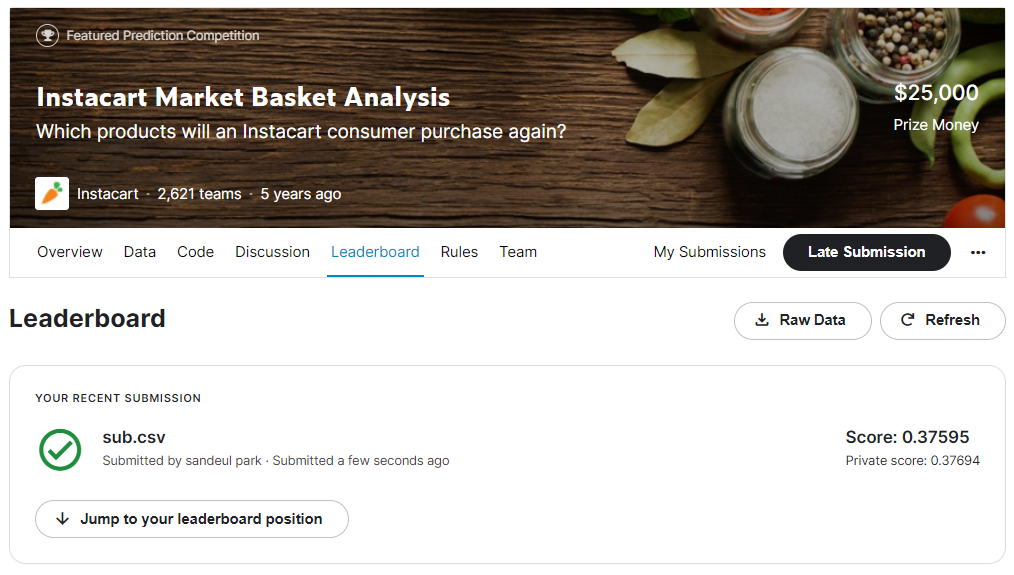